<a href="https://colab.research.google.com/github/aniket-alt/CMPE-258-Deep-Learning/blob/main/Assignment%20-%205/final_activation_functions_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activation Functions for Deep Learning: From Zero to Hero

## A Comprehensive, Beginner-Friendly Guide

---

**Welcome!** This notebook will take you through the fascinating world of activation functions - the components that give neural networks their **power to learn complex patterns**.

### What You'll Learn

- Why activation functions are **essential** for neural networks
- The mathematics behind each activation (explained gently!)
- How to choose the right activation for your task
- Modern activations used in state-of-the-art models

---

### Table of Contents

| Part | Topic | Key Concepts |
|------|-------|-------------|
| I | Why Activations Matter | Linear vs non-linear, universal approximation |
| II | Classic Activations | Sigmoid, Tanh, Step function |
| III | ReLU Revolution | ReLU, dying ReLU problem |
| IV | ReLU Variants | LeakyReLU, PReLU, ELU, SELU |
| V | Modern Activations | GELU, Swish, Mish, SiLU |
| VI | Output Activations | Softmax, Sigmoid for outputs |
| VII | Practical Guide | Choosing the right activation |
| VIII | Hands-on Comparison | Training networks with different activations |


In [1]:
# Install and import dependencies
!pip install -q numpy matplotlib torch scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import make_moons, make_circles
import warnings
warnings.filterwarnings('ignore')

# Set seeds
np.random.seed(42)
torch.manual_seed(42)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")

Libraries loaded successfully!


---

# Part I: Why Activation Functions Matter

---

## 1.1 The Problem with Linear Networks

Without activation functions, neural networks are just **linear transformations**!

### Mathematical Proof

Consider a 2-layer network without activations:

$$\text{Layer 1: } h = W_1 x + b_1$$
$$\text{Layer 2: } y = W_2 h + b_2$$

Substituting:
$$y = W_2(W_1 x + b_1) + b_2 = (W_2 W_1)x + (W_2 b_1 + b_2) = W'x + b'$$

**This is still linear!** No matter how many layers, without activations it collapses to a single linear transformation.

### Why This Matters for Deep Learning

Linear models can only learn:
- Straight line decision boundaries
- Linear relationships between inputs and outputs

They **cannot** learn:
- XOR problem
- Curved decision boundaries
- Complex patterns in images, text, etc.

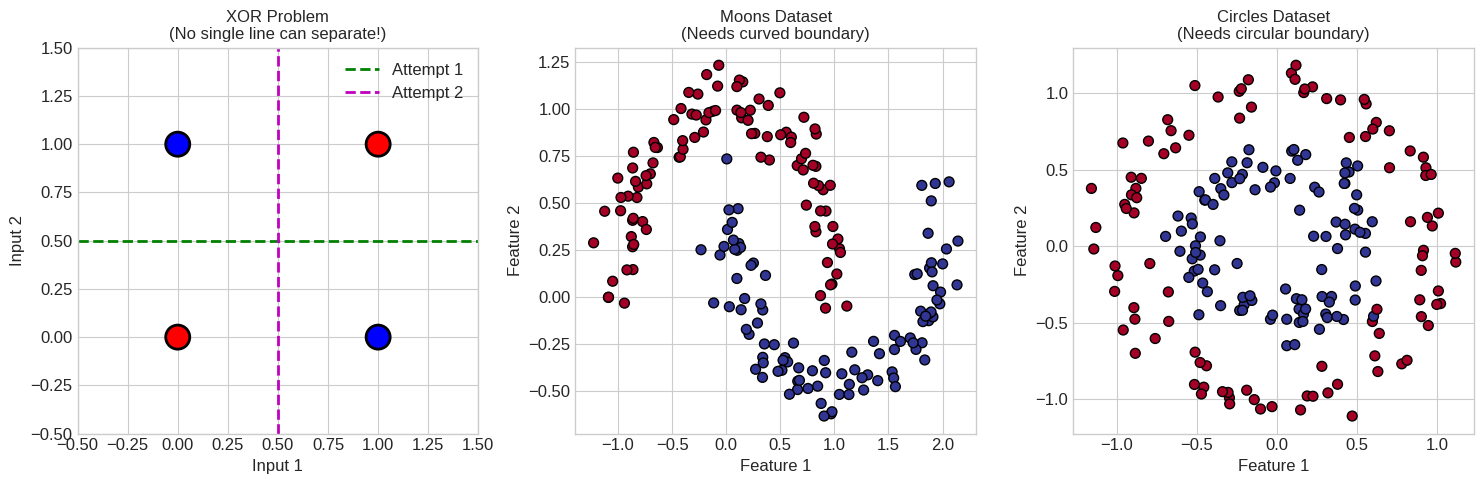


KEY INSIGHT: These problems CANNOT be solved with linear models!
Activation functions add the non-linearity needed to learn
complex decision boundaries.


In [2]:
# Visualize why non-linearity is needed
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Problem 1: XOR (not linearly separable)
ax = axes[0]
xor_X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
xor_y = np.array([0, 1, 1, 0])  # XOR outputs
colors = ['red' if y == 0 else 'blue' for y in xor_y]
ax.scatter(xor_X[:, 0], xor_X[:, 1], c=colors, s=300, edgecolor='black', linewidth=2)
ax.set_xlabel('Input 1')
ax.set_ylabel('Input 2')
ax.set_title('XOR Problem\n(No single line can separate!)', fontsize=12)
# Try to draw a separating line - impossible!
ax.plot([-0.5, 1.5], [0.5, 0.5], 'g--', linewidth=2, label='Attempt 1')
ax.plot([0.5, 0.5], [-0.5, 1.5], 'm--', linewidth=2, label='Attempt 2')
ax.legend()
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)

# Problem 2: Moons dataset
ax = axes[1]
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)
ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='RdYlBu', s=50, edgecolor='black')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Moons Dataset\n(Needs curved boundary)', fontsize=12)

# Problem 3: Circles dataset
ax = axes[2]
X_circles, y_circles = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)
ax.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='RdYlBu', s=50, edgecolor='black')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Circles Dataset\n(Needs circular boundary)', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHT: These problems CANNOT be solved with linear models!")
print("Activation functions add the non-linearity needed to learn")
print("complex decision boundaries.")
print("="*60)

## 1.2 What Activation Functions Do

An activation function $\sigma$ is applied element-wise to the output of a linear layer:

$$a = \sigma(Wx + b)$$

### Key Properties We Want

| Property | Why It Matters |
|----------|----------------|
| **Non-linear** | Enables learning complex patterns |
| **Differentiable** | Needed for backpropagation |
| **Non-saturating** | Prevents vanishing gradients |
| **Zero-centered** | Helps optimization |
| **Computationally efficient** | Fast training and inference |

---

# Part II: Classic Activation Functions

---

## 2.1 Sigmoid (Logistic Function)

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

**Derivative:** $\sigma'(x) = \sigma(x)(1 - \sigma(x))$

### Properties
- Output range: (0, 1)
- Smooth and differentiable everywhere
- Historically important (biological neuron analogy)

### Problems
- **Vanishing gradients**: Saturates at extremes (gradient → 0)
- **Not zero-centered**: All outputs positive
- **Computationally expensive**: Exponential calculation

## 2.2 Tanh (Hyperbolic Tangent)

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

**Derivative:** $\tanh'(x) = 1 - \tanh^2(x)$

### Properties
- Output range: (-1, 1)
- **Zero-centered** (better than sigmoid!)
- Still suffers from vanishing gradients

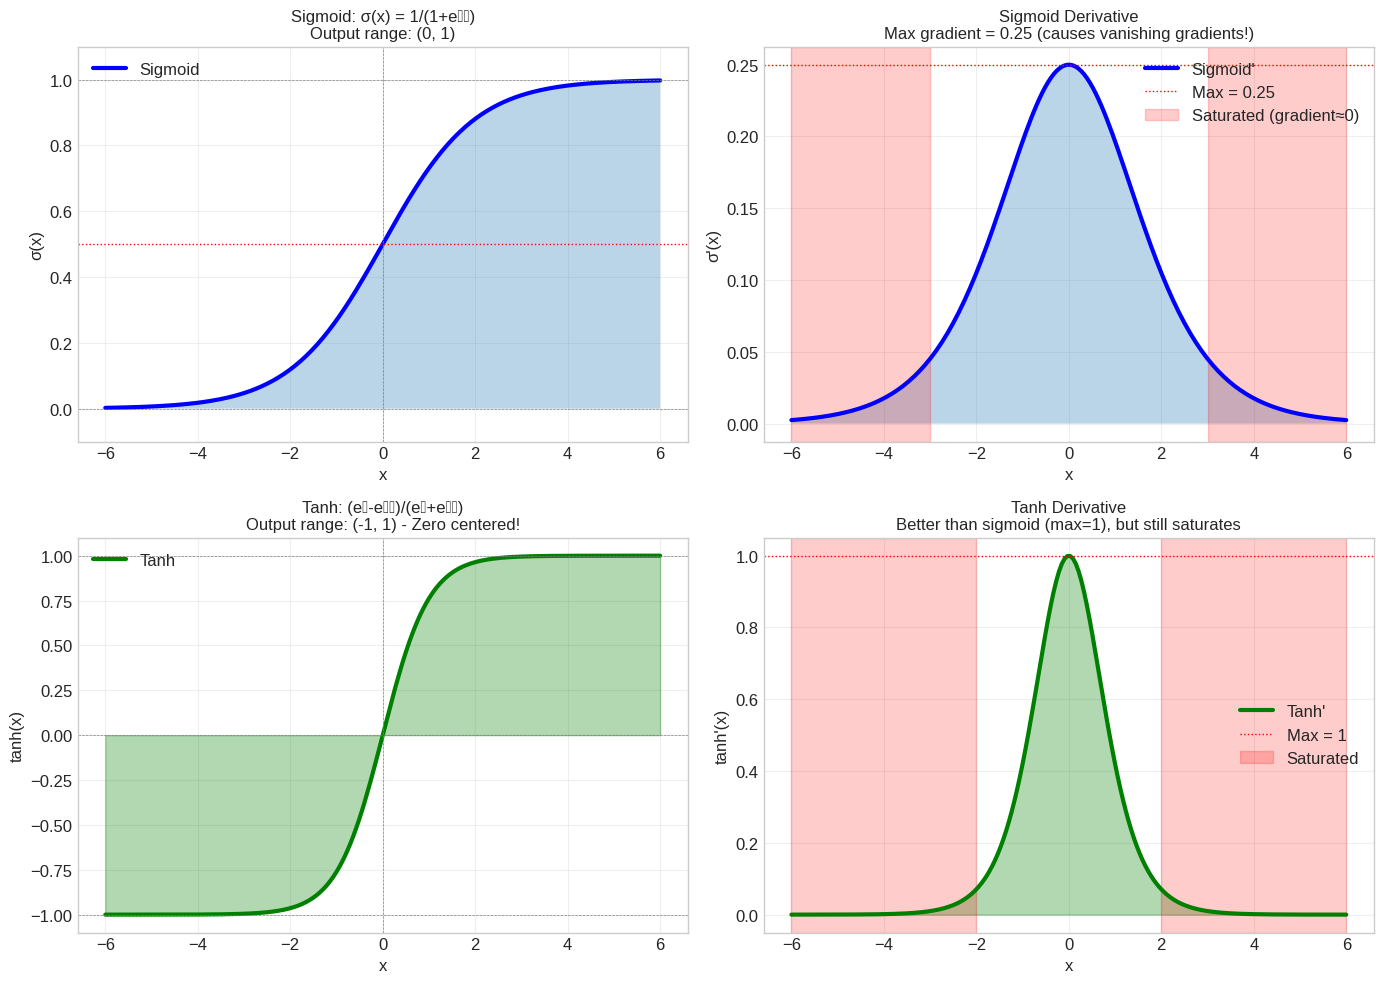


VANISHING GRADIENT PROBLEM:
When gradients are < 1, they shrink exponentially through layers.
Sigmoid max gradient = 0.25 → After 4 layers: 0.25⁴ ≈ 0.004!
This makes deep networks nearly impossible to train.


In [3]:
# Implement and visualize classic activations
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

x = np.linspace(-6, 6, 200)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sigmoid
ax = axes[0, 0]
ax.plot(x, sigmoid(x), 'b-', linewidth=3, label='Sigmoid')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=0.5, color='red', linestyle=':', linewidth=1)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
ax.fill_between(x, sigmoid(x), alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('σ(x)')
ax.set_title('Sigmoid: σ(x) = 1/(1+e⁻ˣ)\nOutput range: (0, 1)', fontsize=12)
ax.legend()
ax.set_ylim(-0.1, 1.1)
ax.grid(True, alpha=0.3)

# Sigmoid derivative
ax = axes[0, 1]
ax.plot(x, sigmoid_derivative(x), 'b-', linewidth=3, label="Sigmoid'")
ax.axhline(y=0.25, color='red', linestyle=':', linewidth=1, label='Max = 0.25')
ax.fill_between(x, sigmoid_derivative(x), alpha=0.3)
# Highlight saturation regions
ax.axvspan(-6, -3, alpha=0.2, color='red', label='Saturated (gradient≈0)')
ax.axvspan(3, 6, alpha=0.2, color='red')
ax.set_xlabel('x')
ax.set_ylabel("σ'(x)")
ax.set_title('Sigmoid Derivative\nMax gradient = 0.25 (causes vanishing gradients!)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Tanh
ax = axes[1, 0]
ax.plot(x, tanh(x), 'g-', linewidth=3, label='Tanh')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=-1, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
ax.fill_between(x, tanh(x), alpha=0.3, color='green')
ax.set_xlabel('x')
ax.set_ylabel('tanh(x)')
ax.set_title('Tanh: (eˣ-e⁻ˣ)/(eˣ+e⁻ˣ)\nOutput range: (-1, 1) - Zero centered!', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Tanh derivative
ax = axes[1, 1]
ax.plot(x, tanh_derivative(x), 'g-', linewidth=3, label="Tanh'")
ax.axhline(y=1, color='red', linestyle=':', linewidth=1, label='Max = 1')
ax.fill_between(x, tanh_derivative(x), alpha=0.3, color='green')
ax.axvspan(-6, -2, alpha=0.2, color='red', label='Saturated')
ax.axvspan(2, 6, alpha=0.2, color='red')
ax.set_xlabel('x')
ax.set_ylabel("tanh'(x)")
ax.set_title('Tanh Derivative\nBetter than sigmoid (max=1), but still saturates', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("VANISHING GRADIENT PROBLEM:")
print("When gradients are < 1, they shrink exponentially through layers.")
print("Sigmoid max gradient = 0.25 → After 4 layers: 0.25⁴ ≈ 0.004!")
print("This makes deep networks nearly impossible to train.")
print("="*60)

---

# Part III: The ReLU Revolution

---

## 3.1 ReLU (Rectified Linear Unit)

$$\text{ReLU}(x) = \max(0, x)$$

**Derivative:**
$$\text{ReLU}'(x) = \begin{cases} 1 & \text{if } x > 0 \\ 0 & \text{if } x \leq 0 \end{cases}$$

### Why ReLU Changed Everything (2010s)

| Advantage | Explanation |
|-----------|-------------|
| **No vanishing gradient** | Gradient is 1 for positive values |
| **Sparse activation** | Many neurons output 0 → efficiency |
| **Computationally cheap** | Just max(0, x) - no exponentials! |
| **Biological plausibility** | Neurons either fire or don't |

### The Catch: Dying ReLU Problem

If a neuron's input is always negative:
- Output is always 0
- Gradient is always 0
- **Neuron "dies" and never recovers!**

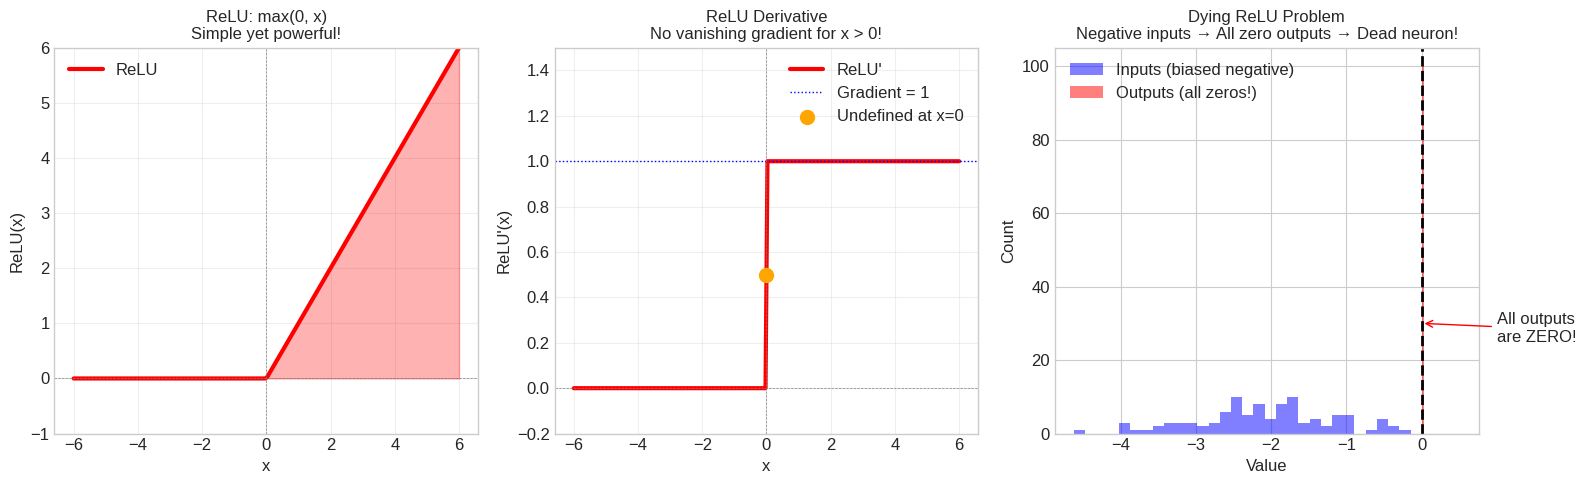


ReLU REVOLUTIONIZED DEEP LEARNING:
• Made training deep networks (10+ layers) possible
• Enabled breakthroughs like AlexNet (2012)
• Still the default choice for hidden layers today


In [4]:
# Visualize ReLU and the dying ReLU problem
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ReLU function
ax = axes[0]
ax.plot(x, relu(x), 'r-', linewidth=3, label='ReLU')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
ax.fill_between(x[x >= 0], relu(x[x >= 0]), alpha=0.3, color='red')
ax.set_xlabel('x')
ax.set_ylabel('ReLU(x)')
ax.set_title('ReLU: max(0, x)\nSimple yet powerful!', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-1, 6)

# ReLU derivative
ax = axes[1]
ax.plot(x, relu_derivative(x), 'r-', linewidth=3, label="ReLU'")
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=1, color='blue', linestyle=':', linewidth=1, label='Gradient = 1')
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
ax.scatter([0], [0.5], color='orange', s=100, zorder=5, label='Undefined at x=0')
ax.set_xlabel('x')
ax.set_ylabel("ReLU'(x)")
ax.set_title('ReLU Derivative\nNo vanishing gradient for x > 0!', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.2, 1.5)

# Dying ReLU illustration
ax = axes[2]
# Simulate a "dead" neuron
np.random.seed(42)
inputs = np.random.randn(100) - 2  # Biased negative inputs
outputs = relu(inputs)

ax.hist(inputs, bins=30, alpha=0.5, label='Inputs (biased negative)', color='blue')
ax.hist(outputs, bins=30, alpha=0.5, label='Outputs (all zeros!)', color='red')
ax.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax.set_xlabel('Value')
ax.set_ylabel('Count')
ax.set_title('Dying ReLU Problem\nNegative inputs → All zero outputs → Dead neuron!', fontsize=12)
ax.legend()
ax.annotate('All outputs\nare ZERO!', xy=(0, 30), xytext=(1, 25),
            fontsize=12, arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ReLU REVOLUTIONIZED DEEP LEARNING:")
print("• Made training deep networks (10+ layers) possible")
print("• Enabled breakthroughs like AlexNet (2012)")
print("• Still the default choice for hidden layers today")
print("="*60)

---

# Part IV: ReLU Variants

---

## 4.1 Leaky ReLU

$$\text{LeakyReLU}(x) = \begin{cases} x & \text{if } x > 0 \\ \alpha x & \text{if } x \leq 0 \end{cases}$$

Typically $\alpha = 0.01$. Allows small gradient for negative values → neurons don't die!

## 4.2 PReLU (Parametric ReLU)

Same as Leaky ReLU, but $\alpha$ is **learned** during training!

## 4.3 ELU (Exponential Linear Unit)

$$\text{ELU}(x) = \begin{cases} x & \text{if } x > 0 \\ \alpha(e^x - 1) & \text{if } x \leq 0 \end{cases}$$

- Smooth curve (vs sharp corner in ReLU)
- Outputs can be negative → closer to zero-centered

## 4.4 SELU (Scaled ELU)

$$\text{SELU}(x) = \lambda \begin{cases} x & \text{if } x > 0 \\ \alpha(e^x - 1) & \text{if } x \leq 0 \end{cases}$$

With specific values ($\lambda \approx 1.0507$, $\alpha \approx 1.6733$), SELU is **self-normalizing** - activations automatically converge to zero mean and unit variance!

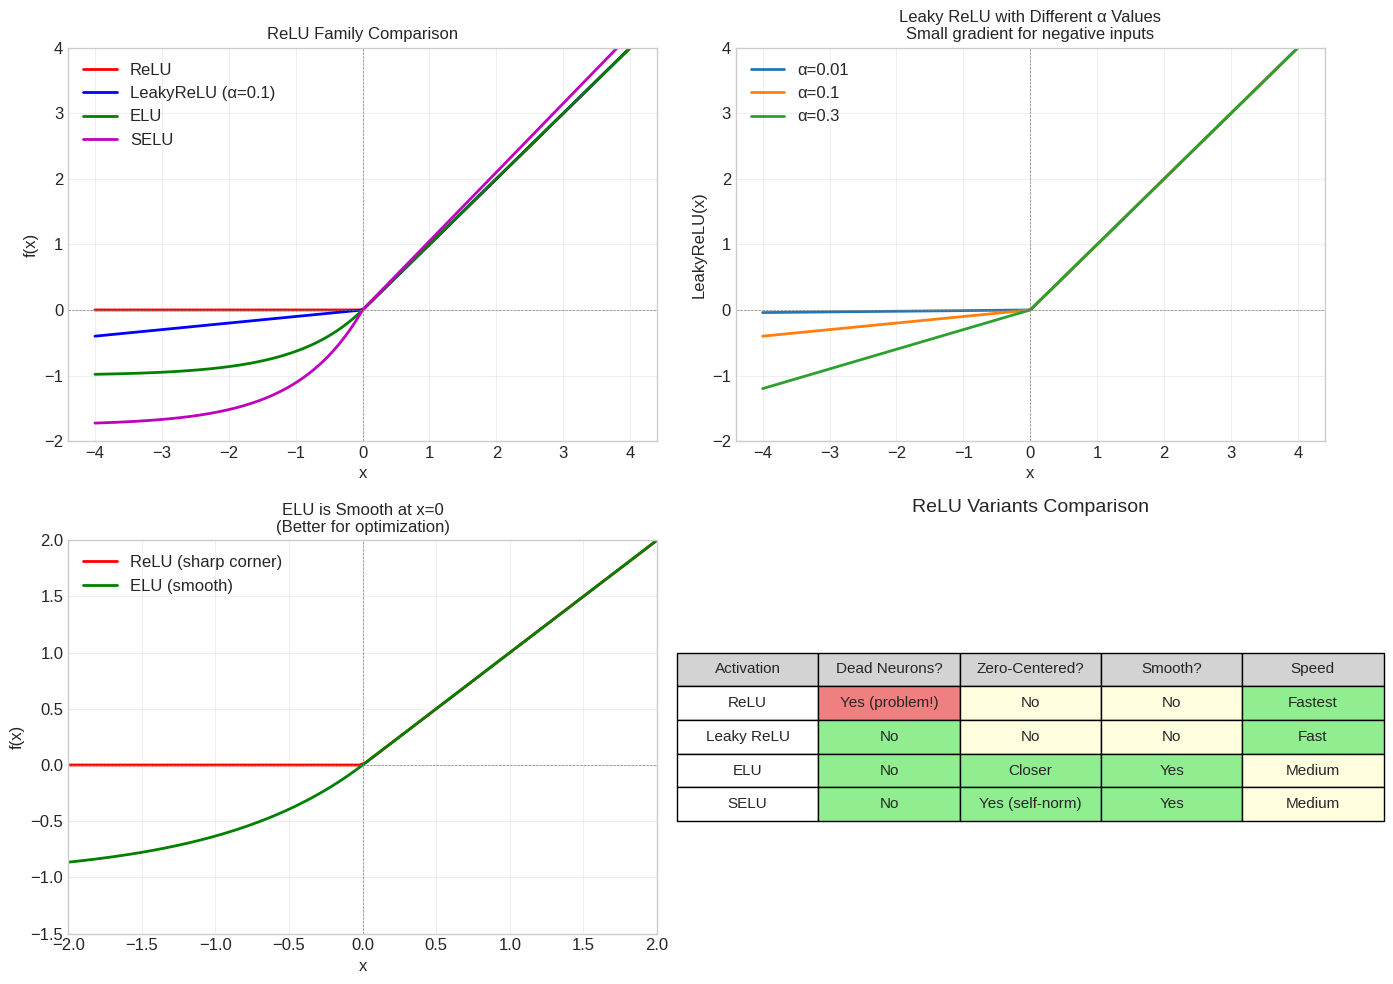

In [5]:
# Implement and visualize ReLU variants
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

def selu(x):
    alpha = 1.6732632423543772
    scale = 1.0507009873554805
    return scale * np.where(x > 0, x, alpha * (np.exp(x) - 1))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x = np.linspace(-4, 4, 200)

# Plot all ReLU variants together
ax = axes[0, 0]
ax.plot(x, relu(x), 'r-', linewidth=2, label='ReLU')
ax.plot(x, leaky_relu(x, 0.1), 'b-', linewidth=2, label='LeakyReLU (α=0.1)')
ax.plot(x, elu(x), 'g-', linewidth=2, label='ELU')
ax.plot(x, selu(x), 'm-', linewidth=2, label='SELU')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('ReLU Family Comparison', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-2, 4)

# Leaky ReLU detail
ax = axes[0, 1]
for alpha in [0.01, 0.1, 0.3]:
    ax.plot(x, leaky_relu(x, alpha), linewidth=2, label=f'α={alpha}')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('LeakyReLU(x)')
ax.set_title('Leaky ReLU with Different α Values\nSmall gradient for negative inputs', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-2, 4)

# ELU smoothness
ax = axes[1, 0]
ax.plot(x, relu(x), 'r-', linewidth=2, label='ReLU (sharp corner)')
ax.plot(x, elu(x), 'g-', linewidth=2, label='ELU (smooth)')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
# Zoom into the corner
ax.set_xlim(-2, 2)
ax.set_ylim(-1.5, 2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('ELU is Smooth at x=0\n(Better for optimization)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Comparison table visualization
ax = axes[1, 1]
ax.axis('off')
table_data = [
    ['Activation', 'Dead Neurons?', 'Zero-Centered?', 'Smooth?', 'Speed'],
    ['ReLU', 'Yes (problem!)', 'No', 'No', 'Fastest'],
    ['Leaky ReLU', 'No', 'No', 'No', 'Fast'],
    ['ELU', 'No', 'Closer', 'Yes', 'Medium'],
    ['SELU', 'No', 'Yes (self-norm)', 'Yes', 'Medium'],
]
colors = [['lightgray']*5,
          ['white', 'lightcoral', 'lightyellow', 'lightyellow', 'lightgreen'],
          ['white', 'lightgreen', 'lightyellow', 'lightyellow', 'lightgreen'],
          ['white', 'lightgreen', 'lightgreen', 'lightgreen', 'lightyellow'],
          ['white', 'lightgreen', 'lightgreen', 'lightgreen', 'lightyellow']]
table = ax.table(cellText=table_data, cellColours=colors, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
ax.set_title('ReLU Variants Comparison', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

---

# Part V: Modern Activations

---

## 5.1 GELU (Gaussian Error Linear Unit)

$$\text{GELU}(x) = x \cdot \Phi(x) = x \cdot \frac{1}{2}\left[1 + \text{erf}\left(\frac{x}{\sqrt{2}}\right)\right]$$

Approximation: $\text{GELU}(x) \approx 0.5x\left(1 + \tanh\left[\sqrt{2/\pi}(x + 0.044715x^3)\right]\right)$

### Why GELU?
- Used in **BERT, GPT, and most modern transformers**
- Smooth approximation of ReLU
- Stochastic regularization interpretation

## 5.2 Swish / SiLU (Sigmoid Linear Unit)

$$\text{Swish}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$

- Discovered by **neural architecture search** (Google)
- Smooth, non-monotonic
- Self-gated (like LSTM gates)

## 5.3 Mish

$$\text{Mish}(x) = x \cdot \tanh(\text{softplus}(x)) = x \cdot \tanh(\ln(1 + e^x))$$

- Even smoother than Swish
- Used in YOLOv4 and other computer vision models

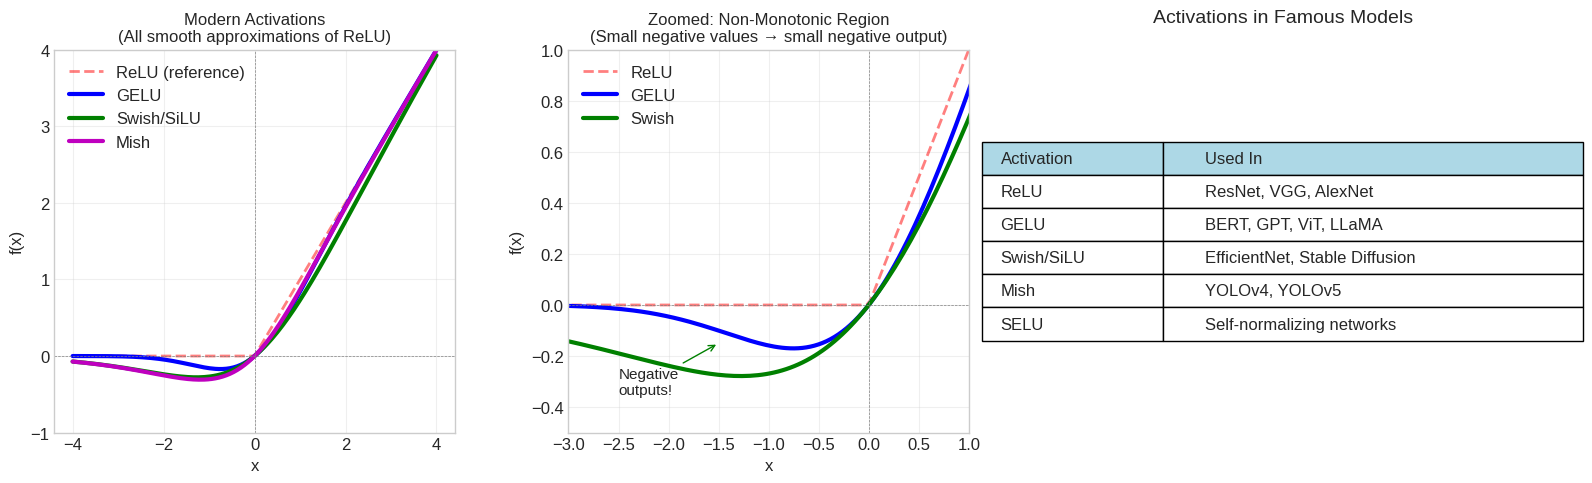


MODERN INSIGHT: GELU is now the standard for transformers!
It's used in BERT, GPT, LLaMA, and most large language models.


In [6]:
# Implement modern activations
def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

def swish(x):
    return x * sigmoid(x)

def mish(x):
    return x * np.tanh(np.log(1 + np.exp(x)))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.linspace(-4, 4, 200)

# Compare all modern activations
ax = axes[0]
ax.plot(x, relu(x), 'r--', linewidth=2, alpha=0.5, label='ReLU (reference)')
ax.plot(x, gelu(x), 'b-', linewidth=3, label='GELU')
ax.plot(x, swish(x), 'g-', linewidth=3, label='Swish/SiLU')
ax.plot(x, mish(x), 'm-', linewidth=3, label='Mish')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Modern Activations\n(All smooth approximations of ReLU)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-1, 4)

# Zoom into the interesting region
ax = axes[1]
ax.plot(x, relu(x), 'r--', linewidth=2, alpha=0.5, label='ReLU')
ax.plot(x, gelu(x), 'b-', linewidth=3, label='GELU')
ax.plot(x, swish(x), 'g-', linewidth=3, label='Swish')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlim(-3, 1)
ax.set_ylim(-0.5, 1)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Zoomed: Non-Monotonic Region\n(Small negative values → small negative output)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.annotate('Negative\noutputs!', xy=(-1.5, -0.15), xytext=(-2.5, -0.35),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='green'))

# Usage in famous models
ax = axes[2]
ax.axis('off')
usage_data = [
    ['Activation', 'Used In'],
    ['ReLU', 'ResNet, VGG, AlexNet'],
    ['GELU', 'BERT, GPT, ViT, LLaMA'],
    ['Swish/SiLU', 'EfficientNet, Stable Diffusion'],
    ['Mish', 'YOLOv4, YOLOv5'],
    ['SELU', 'Self-normalizing networks'],
]
table = ax.table(cellText=usage_data, loc='center', cellLoc='left',
                 colWidths=[0.3, 0.7])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2)
# Color the header
for i in range(2):
    table[(0, i)].set_facecolor('lightblue')
ax.set_title('Activations in Famous Models', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("MODERN INSIGHT: GELU is now the standard for transformers!")
print("It's used in BERT, GPT, LLaMA, and most large language models.")
print("="*60)

---

# Part VI: Output Layer Activations

---

Output activations are different - they depend on your **task**!

## 6.1 For Binary Classification: Sigmoid

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

- Outputs probability between 0 and 1
- Use with **Binary Cross-Entropy loss**

## 6.2 For Multi-class Classification: Softmax

$$\text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

- Outputs sum to 1 (probability distribution)
- Use with **Cross-Entropy loss**

## 6.3 For Regression: None (Linear)

- No activation on output layer
- Can output any real number
- Use with **MSE loss**

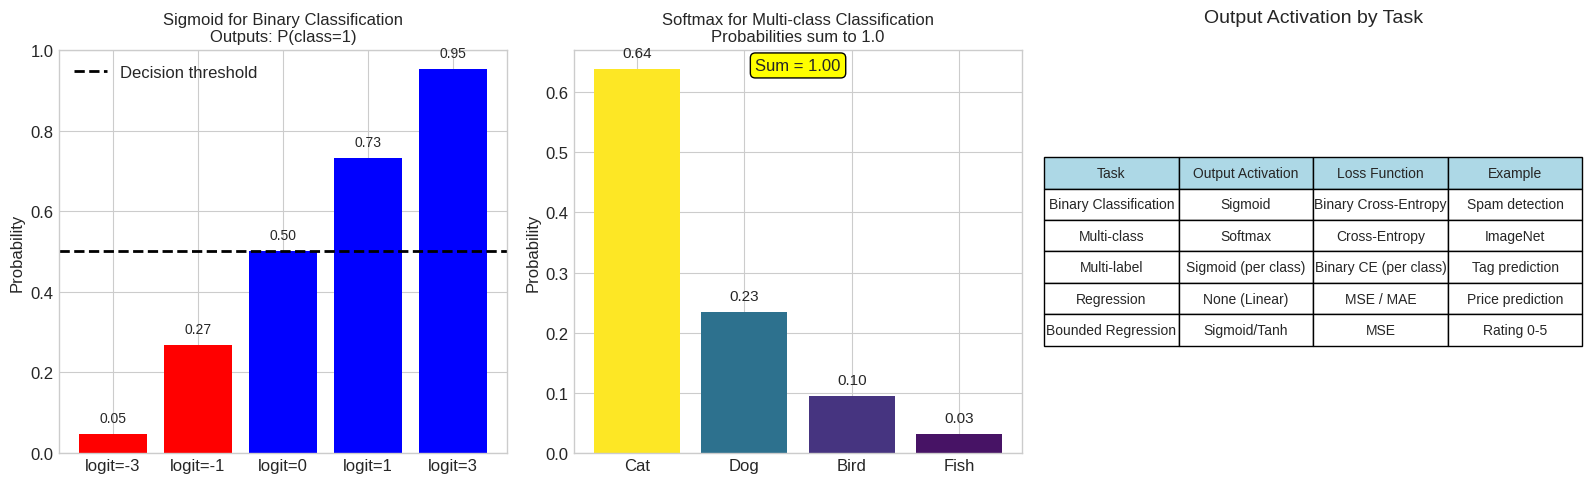

In [7]:
# Visualize output activations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Binary classification with Sigmoid
ax = axes[0]
logits = np.array([-3, -1, 0, 1, 3])
probs = sigmoid(logits)
bars = ax.bar(range(len(logits)), probs, color=['red' if p < 0.5 else 'blue' for p in probs])
ax.axhline(y=0.5, color='black', linestyle='--', linewidth=2, label='Decision threshold')
ax.set_xticks(range(len(logits)))
ax.set_xticklabels([f'logit={l}' for l in logits])
ax.set_ylabel('Probability')
ax.set_title('Sigmoid for Binary Classification\nOutputs: P(class=1)', fontsize=12)
ax.legend()
for i, (l, p) in enumerate(zip(logits, probs)):
    ax.text(i, p + 0.03, f'{p:.2f}', ha='center', fontsize=10)

# Multi-class classification with Softmax
ax = axes[1]
logits_multi = np.array([2.0, 1.0, 0.1, -1.0])
exp_logits = np.exp(logits_multi)
softmax_probs = exp_logits / exp_logits.sum()
colors = plt.cm.viridis(softmax_probs / softmax_probs.max())
bars = ax.bar(['Cat', 'Dog', 'Bird', 'Fish'], softmax_probs, color=colors)
ax.set_ylabel('Probability')
ax.set_title('Softmax for Multi-class Classification\nProbabilities sum to 1.0', fontsize=12)
for i, p in enumerate(softmax_probs):
    ax.text(i, p + 0.02, f'{p:.2f}', ha='center', fontsize=11)
ax.text(0.5, 0.95, f'Sum = {softmax_probs.sum():.2f}', transform=ax.transAxes,
        fontsize=12, ha='center', bbox=dict(boxstyle='round', facecolor='yellow'))

# Task-to-activation mapping
ax = axes[2]
ax.axis('off')
task_data = [
    ['Task', 'Output Activation', 'Loss Function', 'Example'],
    ['Binary Classification', 'Sigmoid', 'Binary Cross-Entropy', 'Spam detection'],
    ['Multi-class', 'Softmax', 'Cross-Entropy', 'ImageNet'],
    ['Multi-label', 'Sigmoid (per class)', 'Binary CE (per class)', 'Tag prediction'],
    ['Regression', 'None (Linear)', 'MSE / MAE', 'Price prediction'],
    ['Bounded Regression', 'Sigmoid/Tanh', 'MSE', 'Rating 0-5'],
]
table = ax.table(cellText=task_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
for i in range(4):
    table[(0, i)].set_facecolor('lightblue')
ax.set_title('Output Activation by Task', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

---

# Part VII: Practical Guide - Choosing Activations

---

## 7.1 Quick Decision Guide

```
                    CHOOSING HIDDEN LAYER ACTIVATION
                              │
                              ▼
              ┌───────────────────────────────┐
              │ What type of network?         │
              └───────────────────────────────┘
                              │
           ┌──────────────────┼──────────────────┐
           │                  │                  │
           ▼                  ▼                  ▼
    ┌─────────────┐   ┌─────────────┐   ┌─────────────┐
    │ Transformer │   │    CNN      │   │    MLP      │
    │  (NLP/LLM)  │   │   (Vision)  │   │  (Tabular)  │
    └─────────────┘   └─────────────┘   └─────────────┘
           │                  │                  │
           ▼                  ▼                  ▼
       ┌───────┐         ┌───────┐         ┌───────┐
       │ GELU  │         │ ReLU  │         │ ReLU  │
       │       │         │  or   │         │  or   │
       │       │         │ SiLU  │         │ SELU  │
       └───────┘         └───────┘         └───────┘
```

## 7.2 Detailed Recommendations

| Network Type | Recommended | Alternative | Avoid |
|--------------|-------------|-------------|-------|
| **Transformers** | GELU | Swish | Sigmoid, Tanh |
| **CNNs** | ReLU, Leaky ReLU | Swish, Mish | Sigmoid |
| **RNNs/LSTMs** | Tanh (gates: Sigmoid) | - | ReLU |
| **MLPs** | ReLU | SELU, Swish | - |
| **GANs** | LeakyReLU | ReLU | Sigmoid (hidden) |

---

# Part VIII: Hands-on Comparison

---

Let's train neural networks with different activations and compare!

In [8]:
# Create dataset
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_tensor = torch.FloatTensor(X)
y_tensor = torch.LongTensor(y)

# Define network with configurable activation
class FlexibleNet(nn.Module):
    def __init__(self, activation='relu'):
        super().__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)

        # Select activation
        if activation == 'relu':
            self.act = nn.ReLU()
        elif activation == 'leaky_relu':
            self.act = nn.LeakyReLU(0.1)
        elif activation == 'elu':
            self.act = nn.ELU()
        elif activation == 'gelu':
            self.act = nn.GELU()
        elif activation == 'silu':
            self.act = nn.SiLU()
        elif activation == 'tanh':
            self.act = nn.Tanh()
        elif activation == 'sigmoid':
            self.act = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        return self.fc3(x)

def train_and_evaluate(activation, epochs=100):
    torch.manual_seed(42)
    model = FlexibleNet(activation)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()

    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    # Final accuracy
    with torch.no_grad():
        preds = model(X_tensor).argmax(dim=1)
        acc = (preds == y_tensor).float().mean().item()

    return losses, acc, model

# Train with different activations
activations = ['relu', 'leaky_relu', 'elu', 'gelu', 'silu', 'tanh', 'sigmoid']
results = {}

for act in activations:
    losses, acc, model = train_and_evaluate(act)
    results[act] = {'losses': losses, 'accuracy': acc, 'model': model}
    print(f"{act:12s}: Final Accuracy = {acc:.2%}")

relu        : Final Accuracy = 98.10%
leaky_relu  : Final Accuracy = 98.00%
elu         : Final Accuracy = 97.60%
gelu        : Final Accuracy = 97.60%
silu        : Final Accuracy = 97.50%
tanh        : Final Accuracy = 97.70%
sigmoid     : Final Accuracy = 87.40%


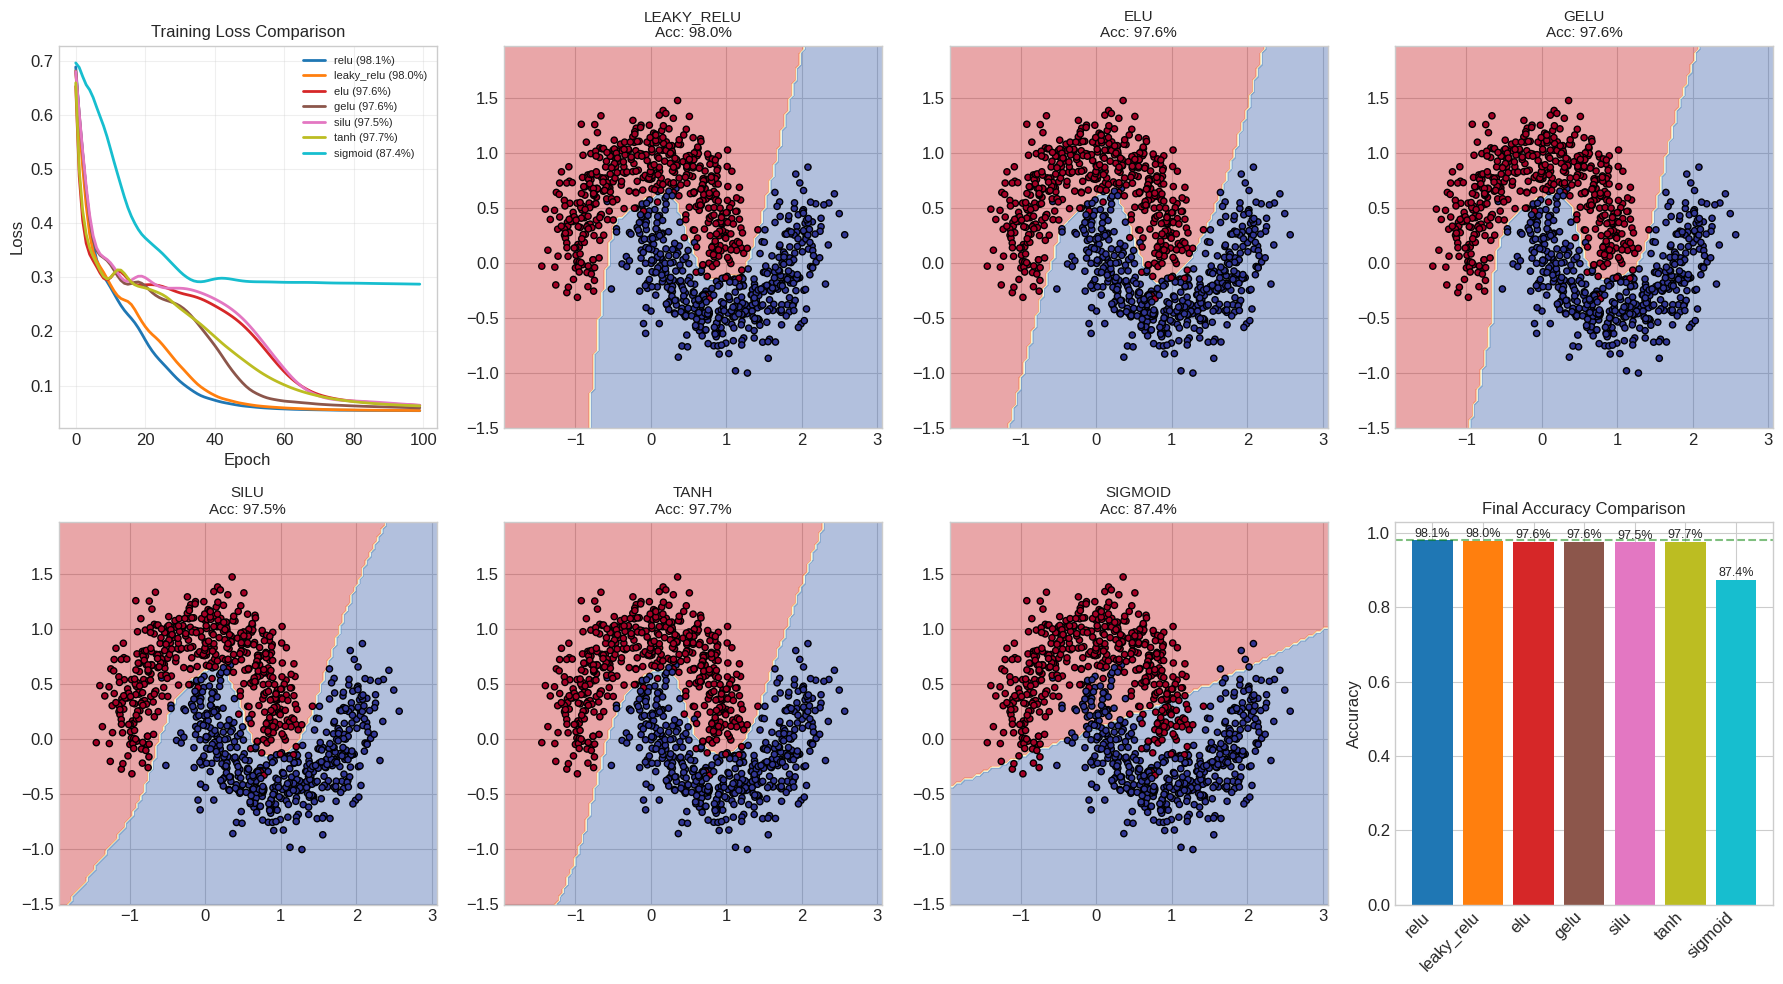

In [9]:
# Visualize results
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# Loss curves
ax = axes[0, 0]
colors = plt.cm.tab10(np.linspace(0, 1, len(activations)))
for (act, data), color in zip(results.items(), colors):
    ax.plot(data['losses'], label=f"{act} ({data['accuracy']:.1%})", color=color, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss Comparison', fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Decision boundaries for each activation
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

for idx, (act, data) in enumerate(list(results.items())[:7]):
    if idx == 0:
        continue  # Skip first (used for loss plot)
    ax = axes.flat[idx]
    model = data['model']
    model.eval()
    with torch.no_grad():
        Z = model(grid).argmax(dim=1).numpy().reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolor='black', s=20)
    ax.set_title(f'{act.upper()}\nAcc: {data["accuracy"]:.1%}', fontsize=11)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

# Final comparison bar chart
ax = axes[1, 3]
accs = [results[act]['accuracy'] for act in activations]
bars = ax.bar(activations, accs, color=colors)
ax.axhline(y=max(accs), color='green', linestyle='--', alpha=0.5)
ax.set_ylabel('Accuracy')
ax.set_title('Final Accuracy Comparison', fontsize=12)
ax.set_xticklabels(activations, rotation=45, ha='right')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---

# Summary: Key Takeaways

---

## What We Learned

1. **Without activations**, neural networks are just linear models

2. **Classic activations** (Sigmoid, Tanh) suffer from vanishing gradients

3. **ReLU revolutionized** deep learning by enabling training of deep networks

4. **ReLU variants** (Leaky, ELU, SELU) solve the dying ReLU problem

5. **Modern activations** (GELU, Swish) are smooth and work best for transformers

6. **Output activations** depend on your task (Softmax, Sigmoid, Linear)

## Quick Reference

```
Hidden Layers:
  - Transformers/LLMs → GELU
  - CNNs → ReLU or Swish
  - MLPs → ReLU or SELU
  - RNNs → Tanh

Output Layer:
  - Binary classification → Sigmoid
  - Multi-class → Softmax
  - Regression → None (Linear)
```

## The Evolution of Activations

```
1940s: Step Function (Perceptron)
  │
1980s: Sigmoid, Tanh (Backprop era)
  │
2010: ReLU (Deep Learning revolution)
  │
2015: Leaky ReLU, ELU, PReLU
  │
2017: SELU (Self-normalizing)
  │
2018: GELU (Transformers), Swish (NAS)
  │
2019: Mish (YOLOv4)
  │
Today: GELU dominates LLMs!
```

**Congratulations!** You now understand activation functions from zero to hero!